In [1]:
!pip install kaleido


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exploratory Data Analysis (EDA)

## Mutual Fund Analytics Capstone

### Objective
Analyze mutual fund datasets to identify trends, patterns, and insights using data visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

In [3]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

In [6]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


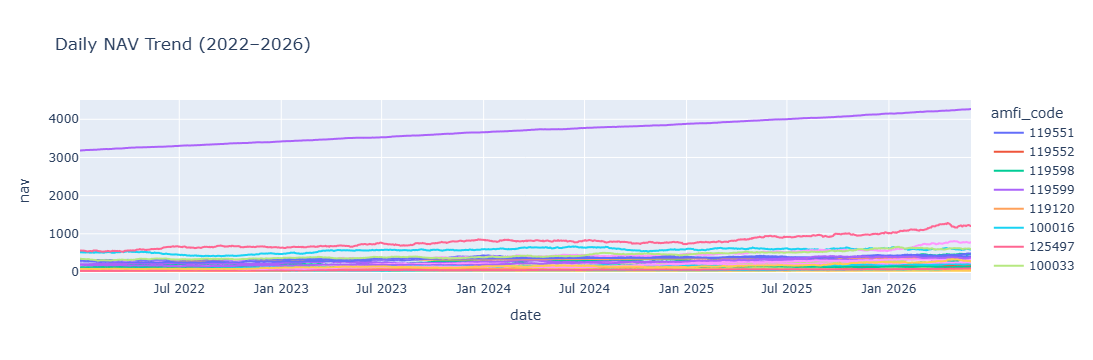

In [8]:
import pandas as pd
import plotly.express as px

# Load NAV data
nav = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Create chart
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()

# Export PNG
fig.write_image(
    "../charts/Figure_1_NAV_Trend.png"
)

## Finding 1: Daily NAV Trend

**Insight:** Most mutual fund schemes showed a steady increase in NAV from 2022 to 2026, indicating positive long-term growth, with brief market corrections during the period.

**Supporting Chart:** Figure 1 – Daily NAV Trend (2022–2026)

# 2. AUM Growth Analysis

In [9]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [10]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

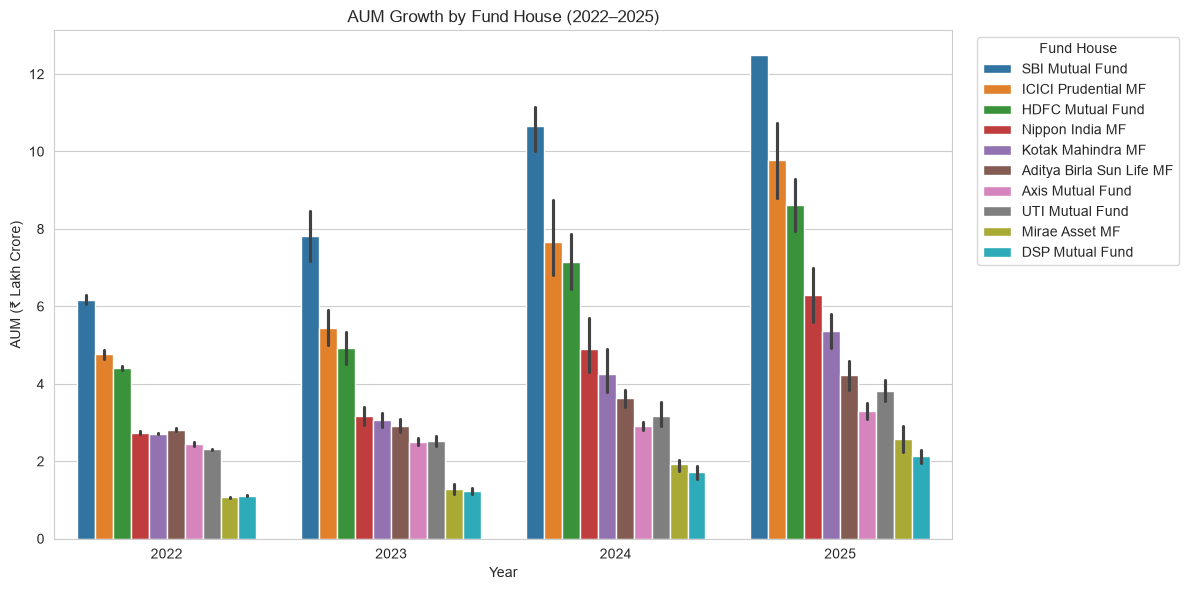

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")


plt.tight_layout()

plt.savefig(
    "../charts/Figure_2_AUM_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 2: AUM Growth

**Insight:** Assets Under Management (AUM) increased steadily across all fund houses from 2022 to 2025. SBI Mutual Fund maintained the highest AUM throughout the period.

**Supporting Chart:** Figure 2 – AUM Growth by Fund House

# 3. Monthly SIP Inflow Trend Analysis

In [12]:
import pandas as pd
import plotly.express as px

# Load SIP data
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [13]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [14]:
sip["month"] = pd.to_datetime(sip["month"])

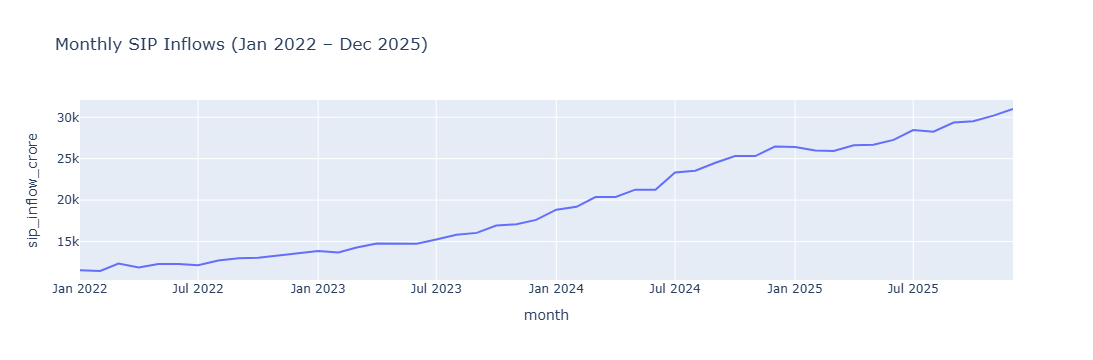

In [15]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)"
)

fig.show()

fig.write_image(
    "../charts/Figure_3_SIP_Inflow.png"
)

## Finding 3: Monthly SIP Inflows

**Insight:** Monthly SIP inflows showed consistent growth from January 2022 to December 2025, reaching an all-time high of ₹31,002 crore in December 2025.

**Supporting Chart:** Figure 3 – Monthly SIP Inflows

# 4. Industry Folio Growth Analysis

In [16]:
import pandas as pd
import plotly.express as px

# Load folio data
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [17]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [18]:
folio["month"] = pd.to_datetime(folio["month"])

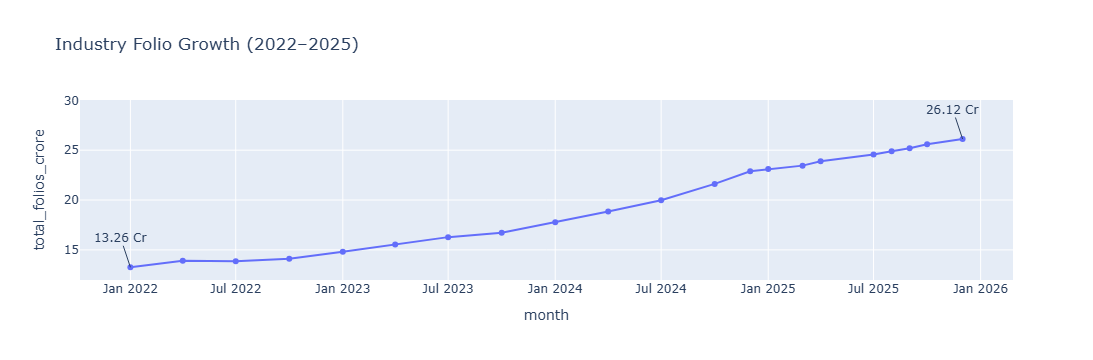

In [19]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Growth (2022–2025)",
    markers=True
)

fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr",
    showarrow=True
)

fig.show()
fig.write_image(
    "../charts/Figure_4_Folio_Growth.png"
)

## Finding 4: Industry Folio Growth

**Insight:** The total number of mutual fund folios increased from **13.26 crore** in January 2022 to **26.12 crore** in December 2025, indicating strong growth in retail investor participation.

**Supporting Chart:** Figure 4 – Industry Folio Growth

In [20]:
import os

print(os.listdir("../data"))
print(os.listdir("../data/processed"))

['processed', 'raw']
['investor_transactions_cleaned.csv', 'nav_history_cleaned.csv', 'scheme_performance_cleaned.csv']


In [21]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_Direct.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [22]:
import pandas as pd

df = pd.read_csv("../data/raw/05_category_inflows.csv")
print(df.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


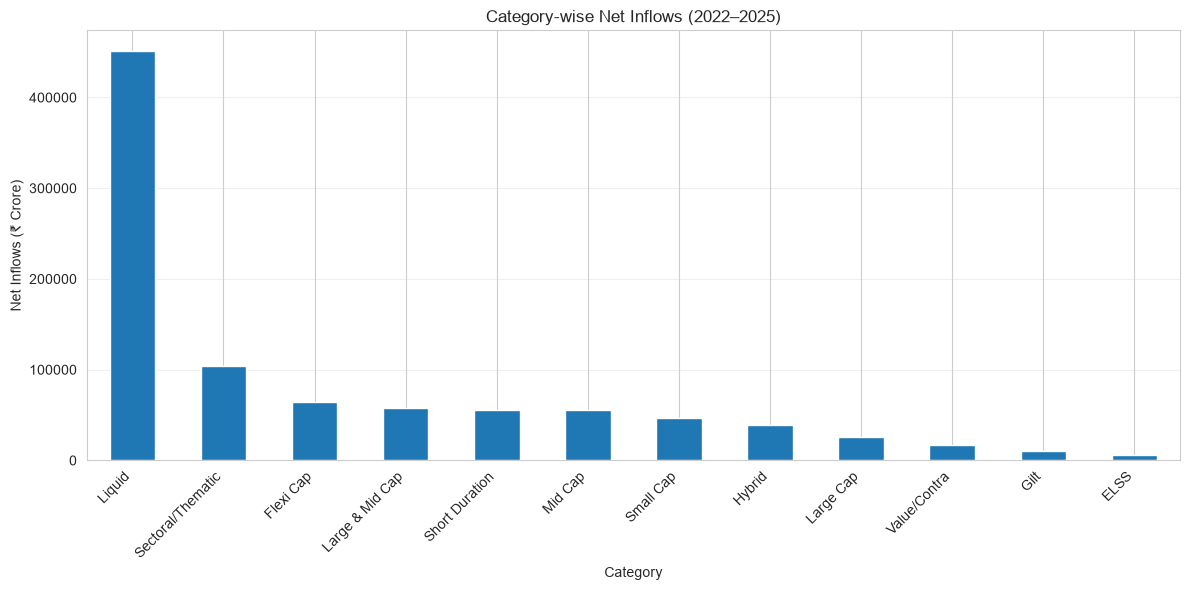

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/05_category_inflows.csv")

# Total inflows by category
category_totals = (
    df.groupby("category")["net_inflow_crore"]
      .sum()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
category_totals.plot(kind="bar")

plt.title("Category-wise Net Inflows (2022–2025)")
plt.xlabel("Category")
plt.ylabel("Net Inflows (₹ Crore)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/Figure_5_Category_Inflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 5: Category-wise Net Inflows

**Insight:** Equity-oriented mutual fund categories attracted the highest cumulative net inflows during 2022–2025, reflecting strong investor preference for long-term wealth creation. Debt and other categories showed comparatively lower inflows, indicating a greater focus on equity investments.

**Supporting Chart:** Figure 5 – Category-wise Net Inflows

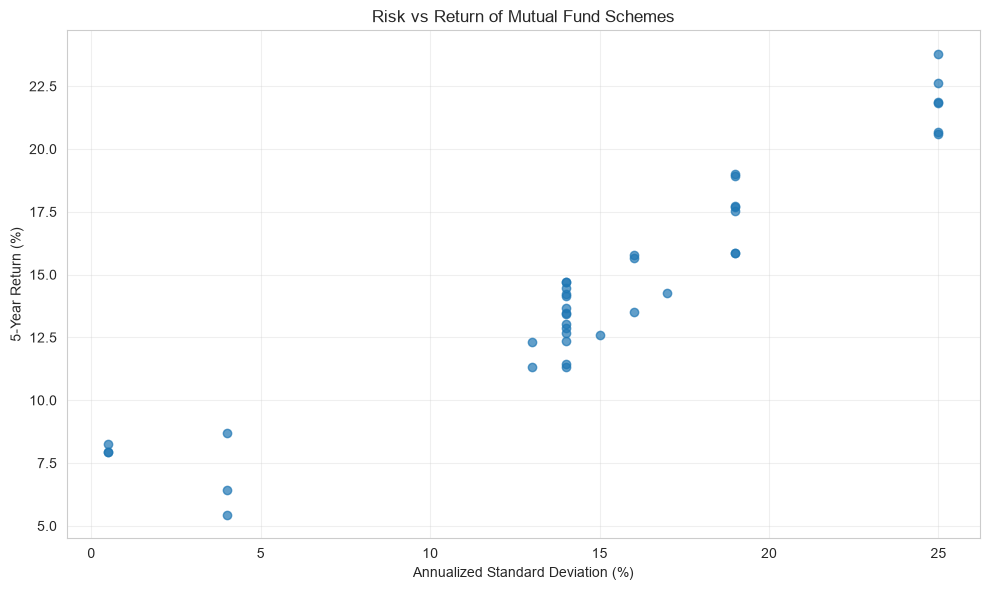

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df["std_dev_ann_pct"],
    df["return_5yr_pct"],
    alpha=0.7
)

plt.title("Risk vs Return of Mutual Fund Schemes")
plt.xlabel("Annualized Standard Deviation (%)")
plt.ylabel("5-Year Return (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.tight_layout()
plt.savefig(
    "charts/Figure_6_Risk_vs_Return.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Finding 6: Risk vs Return Analysis

**Insight:** Schemes with higher long-term returns generally exhibit higher annualized volatility, demonstrating the classic risk–return trade-off in mutual fund investing. Investors seeking higher returns should also be prepared for greater fluctuations.

**Supporting Chart:** Figure 6 – Risk vs Return Scatter Plot

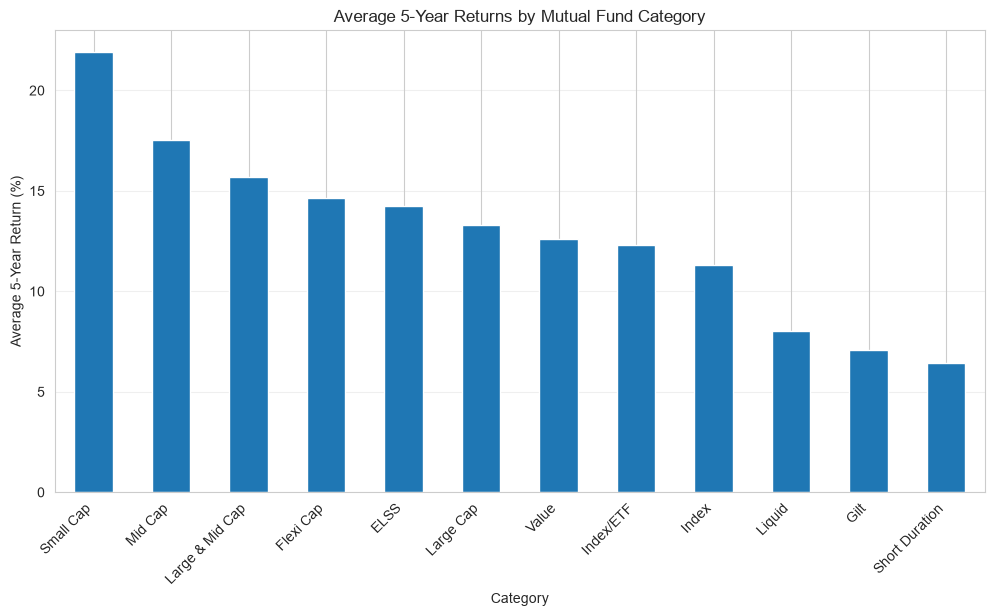

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Average 5-year return by category
avg_returns = (
    df.groupby("category")["return_5yr_pct"]
      .mean()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))
avg_returns.plot(kind="bar")

plt.title("Average 5-Year Returns by Mutual Fund Category")
plt.xlabel("Category")
plt.ylabel("Average 5-Year Return (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "charts/Figure_7_Category_Avg_5Y_Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 7: Category-wise Average 5-Year Returns

**Insight:** Average 5-year returns vary significantly across fund categories. Equity-focused categories delivered stronger long-term performance than conservative categories, highlighting the impact of asset allocation on investment returns.

**Supporting Chart:** Figure 7 – Category-wise Average 5-Year Returns

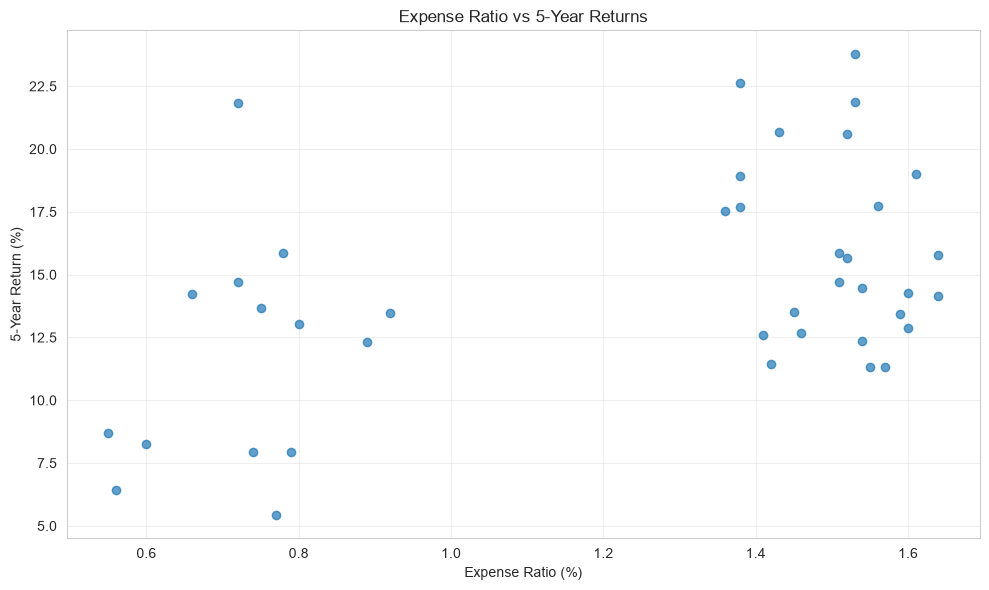

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/07_scheme_performance.csv")

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["expense_ratio_pct"],
    df["return_5yr_pct"],
    alpha=0.7
)

plt.title("Expense Ratio vs 5-Year Returns")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("5-Year Return (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "charts/Figure_8_Expense_vs_Return.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Finding 8: Expense Ratio vs 5-Year Returns

**Insight:** Higher expense ratios do not necessarily translate into better long-term returns. Several funds with relatively low expense ratios achieved competitive 5-year performance, highlighting the importance of evaluating both cost and performance before investing.

**Supporting Chart:** Figure 8 – Expense Ratio vs 5-Year Returns

In [27]:
import pandas as pd

df = pd.read_csv("../data/raw/05_category_inflows.csv")

print(df.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


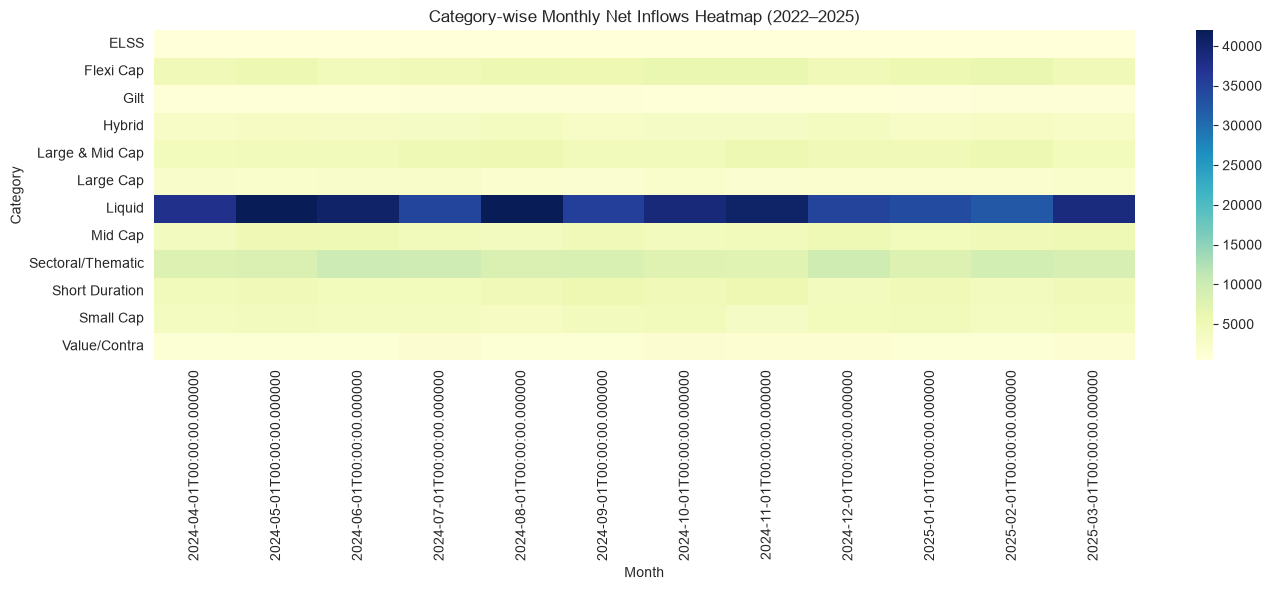

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/05_category_inflows.csv")

df["month"] = pd.to_datetime(df["month"])

# Pivot for heatmap
heatmap_data = df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Monthly Net Inflows Heatmap (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig(
    "charts/Figure_9_Category_Inflow_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Finding 9: Category-wise Inflow Patterns

**Insight:** Monthly inflows varied across categories, with equity categories showing stronger and more consistent investor interest during the analysis period.

**Supporting Chart:** Figure 9 – Category Inflow Heatmap

In [29]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_Direct.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [30]:
import pandas as pd

df = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


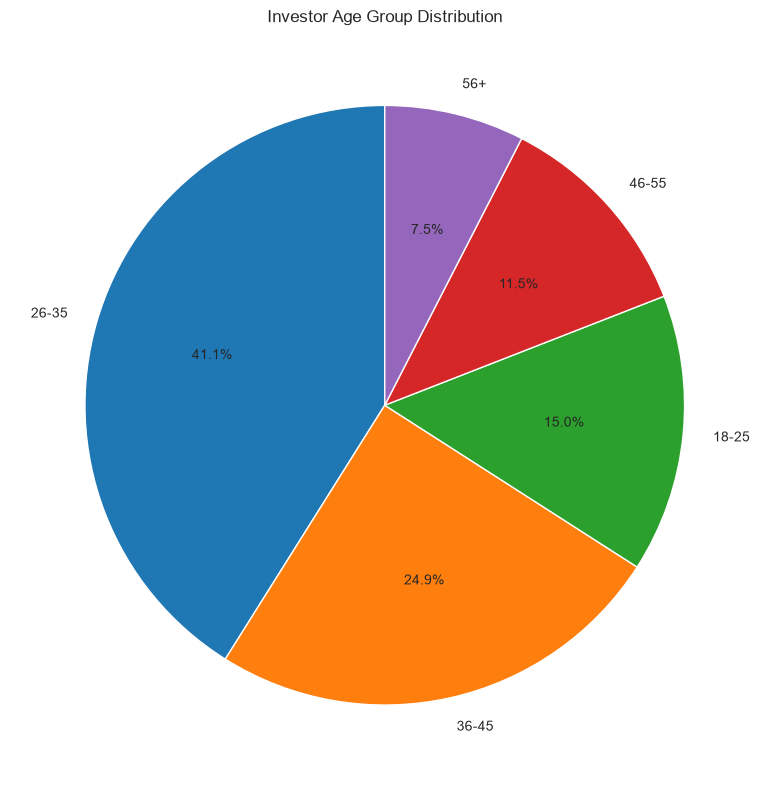

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/08_investor_transactions.csv")

age_distribution = df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.tight_layout()

plt.savefig(
    "charts/Figure_10_Age_Group_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

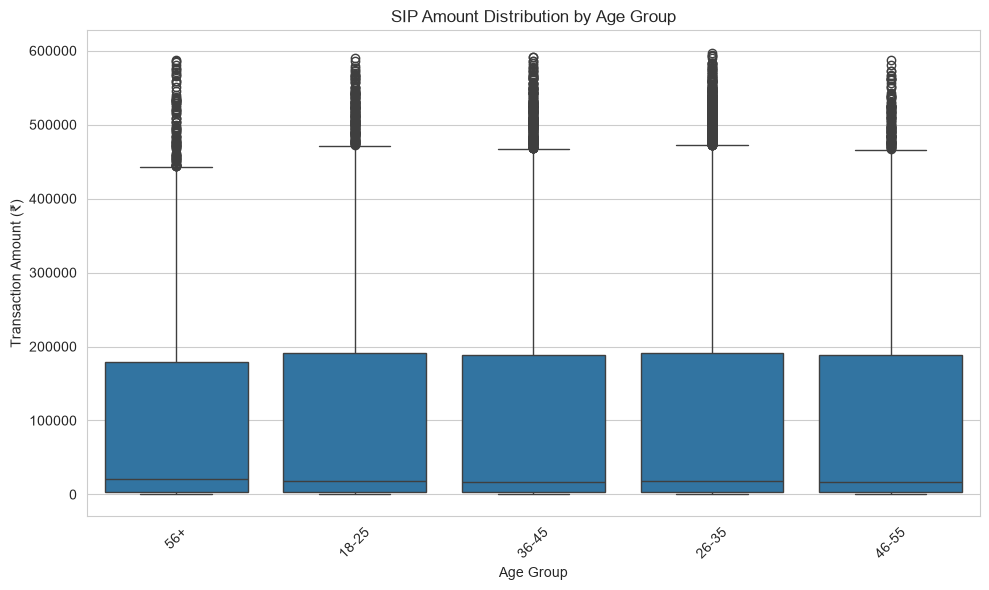

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "charts/Figure_10_SIP_Amount_by_Age.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

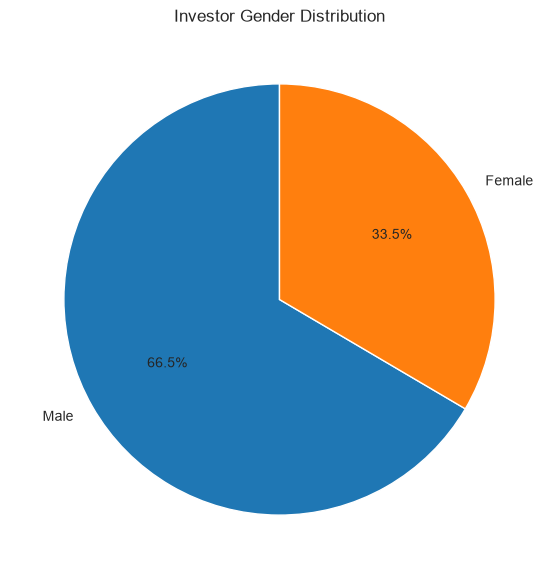

In [33]:
gender_split = df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_split,
    labels=gender_split.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")
plt.savefig(
    "charts/Figure_10_Gender_Split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 10: Investor Demographics

**Insight:** Investor participation is distributed across multiple age groups, with variations in SIP contribution patterns. The demographic analysis highlights differences in investment behavior across age and gender segments.

**Supporting Charts:** Figure 10 – Age Distribution, SIP Amount by Age Group, and Gender Split

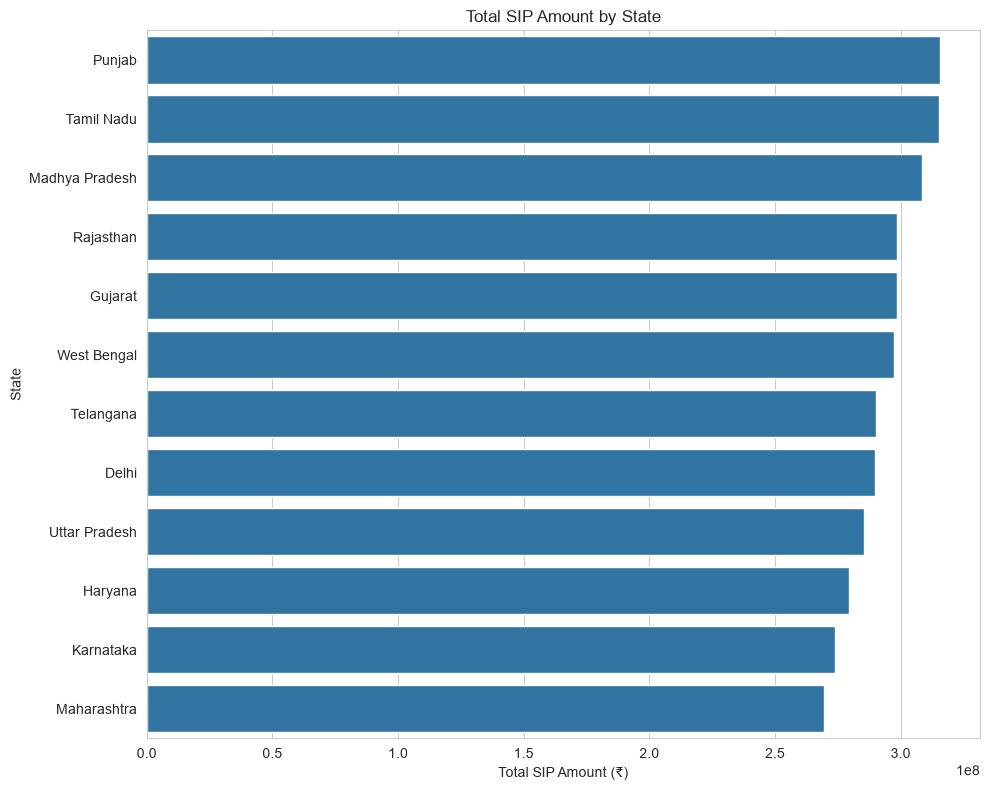

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/08_investor_transactions.csv")

# Total SIP amount by state
state_sip = (
    df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig(
    "charts/Figure_11_Statewise_SIP_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

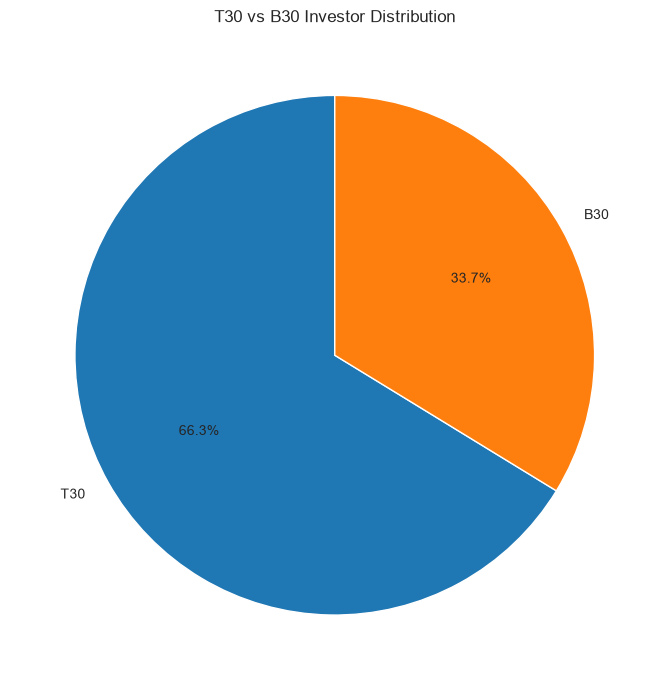

In [35]:
tier_distribution = df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_distribution,
    labels=tier_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")
plt.tight_layout()

plt.savefig(
    "charts/Figure_11_T30_vs_B30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 11: Geographic Distribution of Investors

**Insight:** SIP participation is concentrated in major states and cities, while B30 locations also contribute significantly, showing increasing mutual fund adoption beyond major urban centers.

**Supporting Charts:** Figure 11 – State-wise SIP Amount and T30 vs B30 City Tier Distribution

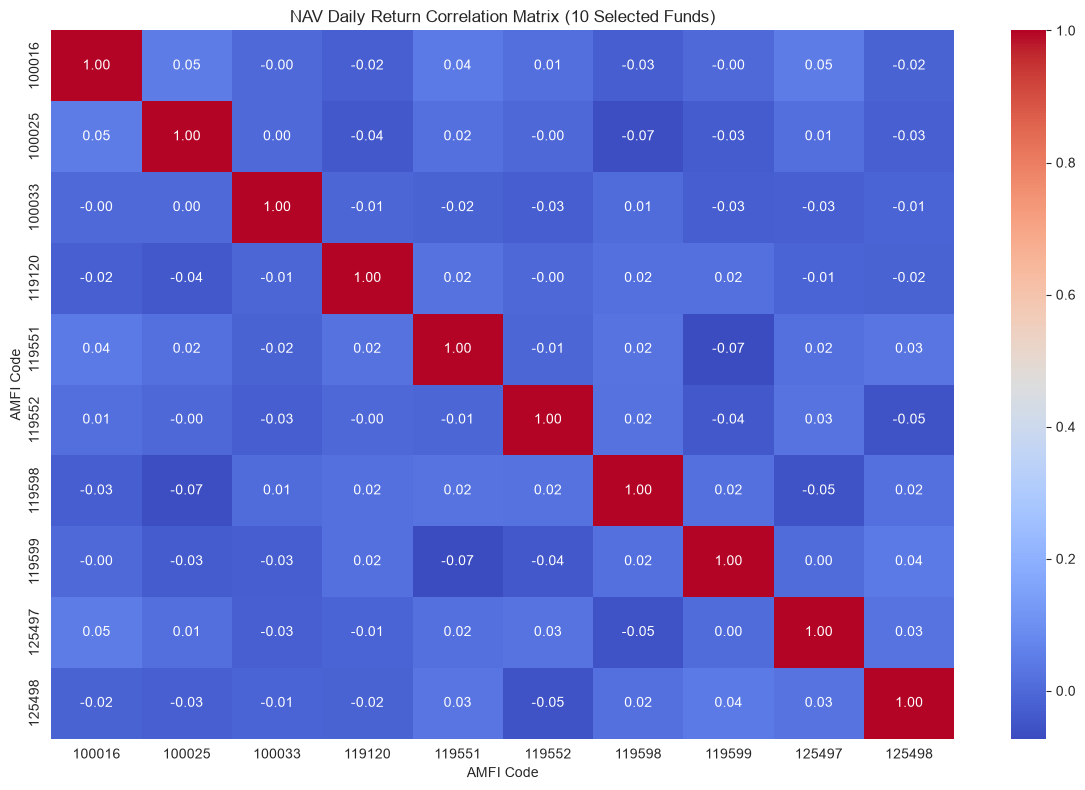

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load NAV data
df = pd.read_csv("../data/raw/02_nav_history.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Select 10 funds
selected_funds = df["amfi_code"].unique()[:10]

# Pivot NAV data
nav_pivot = df[df["amfi_code"].isin(selected_funds)].pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("NAV Daily Return Correlation Matrix (10 Selected Funds)")
plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.tight_layout()
plt.savefig(
    "charts/Figure_12_NAV_Return_Correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Finding 12: NAV Return Correlation

**Insight:** The selected mutual fund schemes show positive correlation in daily returns, indicating that market-wide movements influence fund performance. Lower correlations between some funds suggest opportunities for portfolio diversification.

**Supporting Chart:** Figure 12 – NAV Return Correlation Heatmap

In [37]:
import pandas as pd

df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(df.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


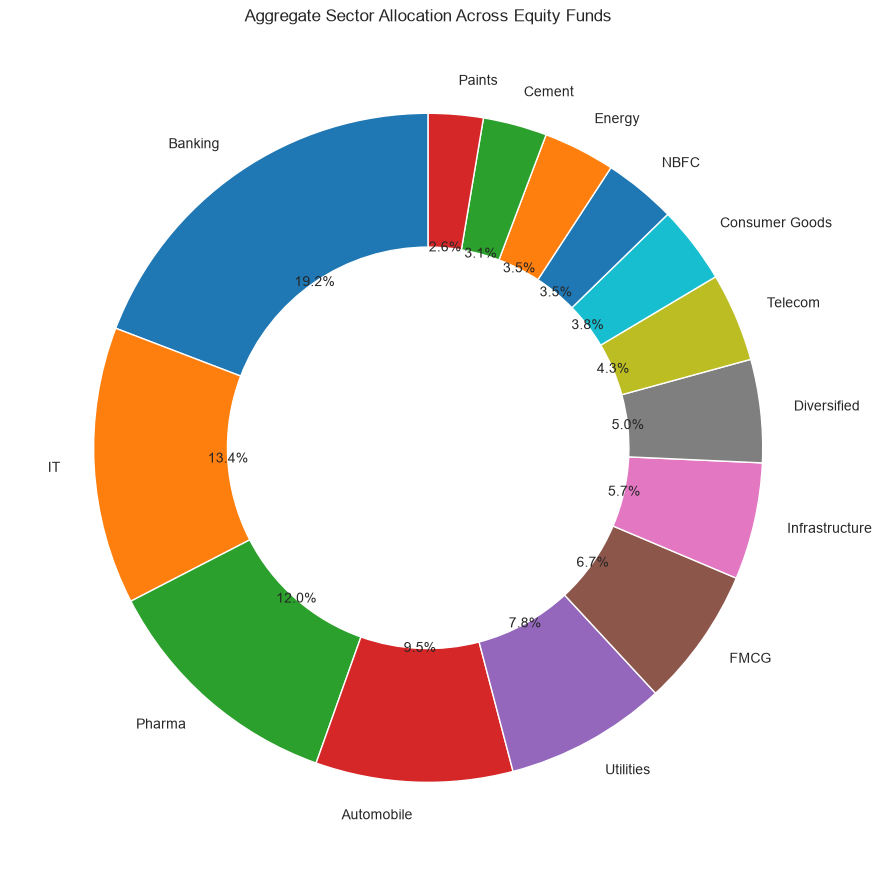

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load portfolio holdings
df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights
sector_allocation = (
    df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Donut chart
plt.figure(figsize=(9,9))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Aggregate Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig(
    "charts/Figure_13_Sector_Allocation_Donut.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Finding 13: Sector Allocation

**Insight:** Equity mutual fund portfolios show diversified exposure across multiple sectors, with major sectors contributing significant portions of overall portfolio allocation.

**Supporting Chart:** Figure 13 – Sector Allocation Donut Chart